**Mubaraq Odumeso**|
A20614610 |
CS584 |
Spring 2026

# Assignment 4

## Problem 1
 - Dataser preparation

In [1]:
import os
import random
import numpy as np
import tensorflow as tf

os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)

In [2]:
from tensorflow.keras import mixed_precision
print(mixed_precision.global_policy())

<DTypePolicy "float32">


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, preprocessing
from sklearn.model_selection import train_test_split
import numpy as np
# from tensorflow.keras.preprocessing.sequence import pad_sequences
import keras_hub
TransformerEncoderLayer = keras_hub.layers.TransformerEncoder
# import keras_nlp
# TransformerEncoderLayer = keras_nlp.layers.TransformerEncoder
    
max_features = 10000
maxlen = 200

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)
x_train_full = keras.preprocessing.sequence.pad_sequences(x_train_full, maxlen=maxlen) # pad sequence ensures each column and row are the same hence max_len.
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

# vectolayers.TextVectorization(max_tokens=5000)

def print_split_stats(name, data, labels):
    lengths = [len(x) for x in data]
    print(f"--- {name} Statistics ---")
    print(f"Samples: {len(data)}")
    print(f"Label Distribution (Positive %): {np.mean(labels) * 100:.2f}%")
    print(f"Sequence Lengths -> Min: {np.min(lengths)}, Max: {np.max(lengths)}, Mean: {np.mean(lengths):.2f}")
    print(f"Shape: {data.shape}")
    print("-" * 30)

# Execute for each split
print_split_stats("Training Set", x_train, y_train)
print_split_stats("Validation Set", x_val, y_val)
print_split_stats("Test Set", x_test, y_test)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Training Set Statistics ---
Samples: 20000
Label Distribution (Positive %): 49.69%
Sequence Lengths -> Min: 200, Max: 200, Mean: 200.00
Shape: (20000, 200)
------------------------------
--- Validation Set Statistics ---
Samples: 5000
Label Distribution (Positive %): 51.26%
Sequence Lengths -> Min: 200, Max: 200, Mean: 200.00
Shape: (5000, 200)
------------------------------
--- Test Set Statistics ---
Samples: 25000
Label Distribution (Positive %): 50.00%
Sequence Lengths -> Min: 200, Max: 200, Mean: 200.00
Shape: (25000, 200)
------------------------------


## Probelm 2
 - Transformer with keras 

unit arg controls neuron output 

In [4]:
import matplotlib.pyplot as plt
from datetime import datetime
def log_run_with_plots(history, extra_info=None):

    epochs = range(1, len(history.history["loss"]) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history["loss"], "b-", label="Training loss")
    plt.plot(epochs, history.history["val_loss"], "r-", label="Validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training and validation loss")
    plt.grid(True, alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history["accuracy"], "b-", label="Training accuracy")
    plt.plot(epochs, history.history["val_accuracy"], "r-", label="Validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Training and validation accuracy")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    
def tablize(results, extras = None):
    
    
    import pandas as pd
    df_tune = pd.DataFrame(results)
    print(df_tune.to_string(index=False))


 2 Number of Heads : 1 encoder layer(s) : 0.001 lamdas : 3e-05 learning rate : 32 batch size
<KerasTensor shape=(None, 200, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_2>
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.5060 - loss: 0.8675 - precision: 0.5030 - val_accuracy: 0.5370 - val_loss: 0.8529 - val_precision: 0.5662 - learning_rate: 3.0000e-05
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5049 - loss: 0.8518 - precision: 0.5015 - val_accuracy: 0.5672 - val_loss: 0.8424 - val_precision: 0.5553 - learning_rate: 3.0000e-05
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5048 - loss: 0.8404 - precision: 0.5014 - val_accuracy: 0.6038 - val_loss: 0.8301 - val_precision: 0.6714 - learning_rate: 3.0000e-05
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5203 - loss: 0.8290 - precision: 0.5197 - val_accuracy: 0.6060 - val_loss: 0.8149 - val_precision: 0.5691 - learning_rate: 3.0000e-05
Epoc

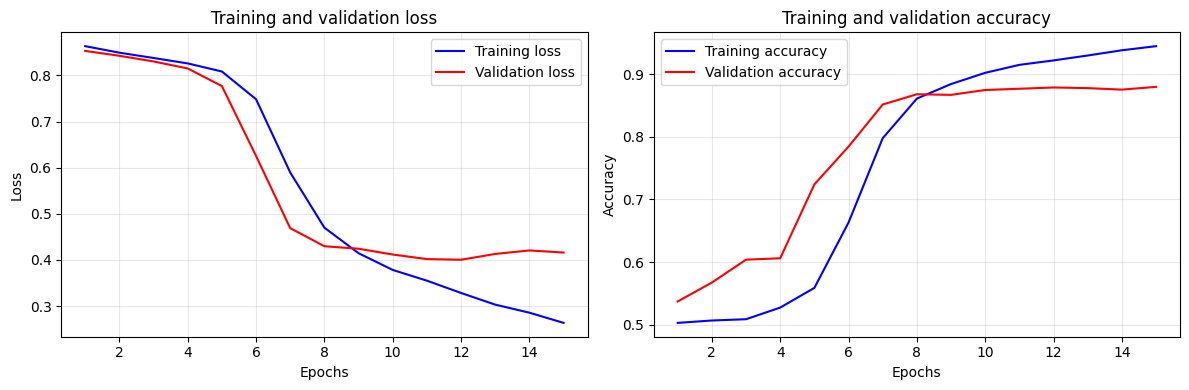

best_epoch 11 val_loss 0.40057486295700073 val_acc 0.8787999749183655

 2 Number of Heads : 1 encoder layer(s) : 0.0001 lamdas : 3e-05 learning rate : 32 batch size
<KerasTensor shape=(None, 200, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_15>
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.4961 - loss: 0.7182 - precision: 0.4946 - val_accuracy: 0.5202 - val_loss: 0.7089 - val_precision: 0.5882 - learning_rate: 3.0000e-05
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5005 - loss: 0.7109 - precision: 0.4973 - val_accuracy: 0.5414 - val_loss: 0.7079 - val_precision: 0.5741 - learning_rate: 3.0000e-05
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5041 - loss: 0.7098 - precision: 0.5008 - val_accuracy: 0.6422 - val_loss: 0.7048 - val_precision: 0.6970 - learning_rate: 3.0000e-05
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5339 - loss: 0.7057 - precision: 0.5283 - val_accuracy: 0.6926 - va

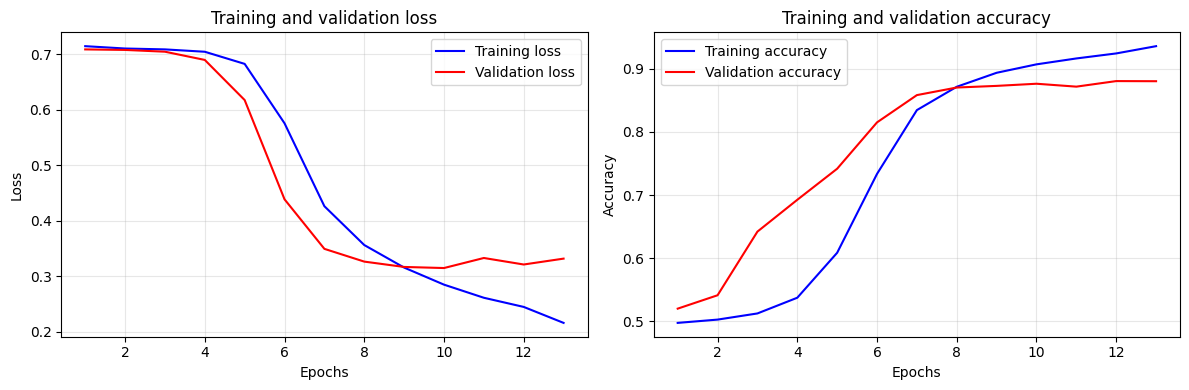

best_epoch 9 val_loss 0.31465944647789 val_acc 0.8763999938964844

 2 Number of Heads : 1 encoder layer(s) : 1e-06 lamdas : 3e-05 learning rate : 32 batch size
<KerasTensor shape=(None, 200, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_28>
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.5009 - loss: 0.6991 - precision: 0.4971 - val_accuracy: 0.5166 - val_loss: 0.6924 - val_precision: 0.5148 - learning_rate: 3.0000e-05
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.5021 - loss: 0.6955 - precision: 0.4986 - val_accuracy: 0.5352 - val_loss: 0.6922 - val_precision: 0.5260 - learning_rate: 3.0000e-05
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5165 - loss: 0.6925 - precision: 0.5134 - val_accuracy: 0.5452 - val_loss: 0.6903 - val_precision: 0.5307 - learning_rate: 3.0000e-05
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5086 - loss: 0.6934 - precision: 0.5049 - val_accuracy: 0.6190 - val_l

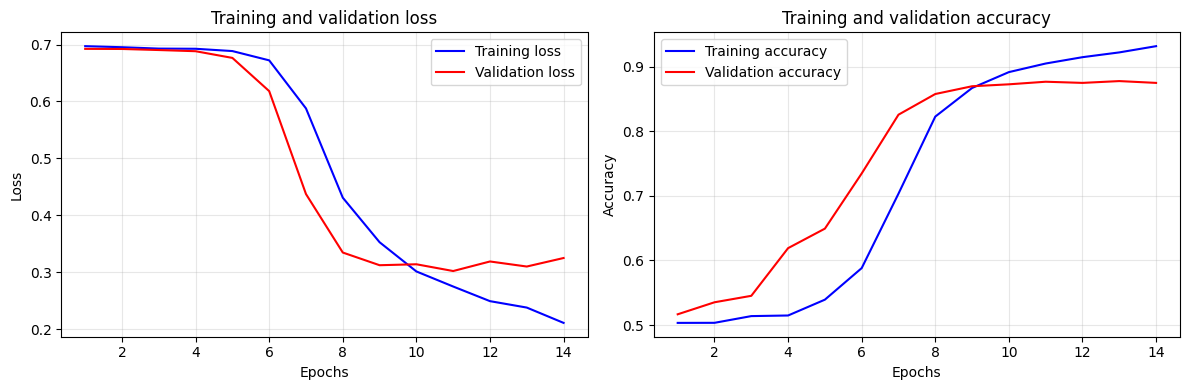

best_epoch 10 val_loss 0.3020266890525818 val_acc 0.8766000270843506

 2 Number of Heads : 2 encoder layer(s) : 0.001 lamdas : 3e-05 learning rate : 32 batch size
<KerasTensor shape=(None, 200, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_41>
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.5049 - loss: 0.8815 - precision: 0.4997 - val_accuracy: 0.5508 - val_loss: 0.8548 - val_precision: 0.5469 - learning_rate: 3.0000e-05
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5048 - loss: 0.8565 - precision: 0.5014 - val_accuracy: 0.5868 - val_loss: 0.8439 - val_precision: 0.5872 - learning_rate: 3.0000e-05
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5195 - loss: 0.8435 - precision: 0.5200 - val_accuracy: 0.5908 - val_loss: 0.8303 - val_precision: 0.6966 - learning_rate: 3.0000e-05
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.5291 - loss: 0.8326 - precision: 0.5319 - val_accuracy: 0.6794 - v

In [ ]:


## Token + positional embedding 
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)
    def call(self, x):
        seq_len = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        position_embeddings = self.pos_emb(positions)
        token_embeddings = self.token_emb(x)
        return token_embeddings + position_embeddings
embed_dim=64  # incresing embed dim to 128 lead to really bad readings
ff_dim = 64
## Baseline Transformer model
def build_model_buitlin(num_encoder_layers=1, num_heads=2, lamda=1e-4):
    inputs = layers.Input(shape=(maxlen,))
    x = TokenAndPositionEmbedding(maxlen, vocab_size=max_features, embed_dim=embed_dim)(inputs)
    tf.print(x)
    for _ in range(num_encoder_layers):
        x = TransformerEncoderLayer(
            intermediate_dim=ff_dim,
            num_heads=num_heads,
            dropout=0.4,
        )(x)
    l2 = keras.regularizers.l2(lamda)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(32, activation="relu", kernel_regularizer=l2)(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=l2)(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=l2)(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    
    return keras.Model(inputs, outputs)

# learning rate scheduler
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    min_delta=1e-4
)
encoder_layers =  [1,2, 3]
num_heads = [2,3]
results = []
lamdas = [1e-3, 1e-4, 1e-6]
learning_rate = [3e-5, 1e-4, 3e-4]
batch_size = [32, 64]
for lr in learning_rate:
    for bs in batch_size:
        for nh in num_heads:
            for el in encoder_layers:
                for lam in lamdas:
                    print(f"\n {nh} Number of Heads : {el} encoder layer(s) : {lam} lamdas : {lr} learning rate : {bs} batch size")
                    model = build_model_buitlin(num_encoder_layers=el,num_heads=nh, lamda=lam)
                    # optimizer = keras.optimizers.Adam(learning_rate=lr)
                    optimizer = keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-5)
                    
                    model.compile(
                                    optimizer=optimizer,
                                  loss='binary_crossentropy', 
                                  metrics =['accuracy', 'precision']
                                  )
                    
                    history = model.fit(x_train, y_train, 
                            epochs          = 20,
                            validation_data = (x_val, y_val),
                            callbacks       = [reduce_lr, early_stop],
                            batch_size=bs,
                            verbose=1)
                    model.evaluate(x_test, y_test)
                    log_run_with_plots(history=history)
                    
                    
                    val_acc = history.history["val_accuracy"][-1]
                    acc = history.history["accuracy"][-1]
                    val_loss = history.history["val_loss"][-1]
                    loss = history.history["loss"][-1]
                                
                    results.append({
                        "num_heads": nh,
                        "el": el,
                        "lamdas": lam,
                        "learning_rate": lr,
                        "batch size": bs,
                        "val_accuracy": round(val_acc, 4),
                        "val_loss": round(val_loss, 4),
                        "acc_gap": acc-val_acc,
                        "loss_gap": loss-val_loss,  
                    })
                    # report best epoch, not last:
                    best = int(np.argmin(history.history["val_loss"]))
                    print("best_epoch", best,
                          "val_loss", history.history["val_loss"][best],
                          "val_acc", history.history["val_accuracy"][best])
tablize(results)

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
def check_best_model(results):
    max_val_acc = results[0]['val_accuracy']
    min_acc_gap = results[0]['acc_gap']
    index = 0

    for i, res in enumerate(results):
        
        # if res['val_accuracy'] > max_val_acc:
        #     max_val_acc = res['val_accuracy']
        #     index = i
        if res['acc_gap'] < min_acc_gap:
            min_acc_gap = res['acc_gap']
            index=i
            
    print("Best model")
    tablize([results[index]])
    
check_best_model(results)

Best model
 num_heads  el  lamdas  val_accuracy  val_loss  acc_gap  loss_gap
         2   3   0.001        0.8828    0.4474  0.04195 -0.133801


BEST READING EVER: 
On 
num_heads  el  val_accuracy  val_loss  acc_gap  loss_gap
         3   1        0.8796    0.3197  0.05455 -0.105382  lamda 1e-4    still overfitting


Best model
 num_heads  el   lamdas  val_accuracy  val_loss  acc_gap  loss_gap   still overfitting
         3   1 0.000001        0.8844    0.3242  0.05975 -0.144382


Added a third layer awaiting results: 


We could increase nmber of epochs. (15)


performance on 2 heads and 3 encoder layers seems better but still low at 0.6506
8 heads and 1 layer accuracy 0.6764 precision 0.6813 
Added validation data (forgot to last time):
significant improvement 
h --- head
el --- encoder layer

1h - 1el underfitting
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7087 - loss: 0.5208 - precision: 0.7124 - val_accuracy: 0.8804 - val_loss: 0.2765 - val_precision: 0.8907
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8760 - loss: 0.2912 - precision: 0.8852

With every other h and el combination ther is severe overfitting and underfitting 

observation on 1 head and >1 layers lead to overfitting  due to **vanishing gradients**


- embed_dim = 128
BAD just bad 

- 2:1 best right now


## Problem 3
- Custom Transformer Block


In [ ]:
class  TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )
        
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim)
        ])
        
        self.layernorm1=layers.LayerNormalization()
        self.layernorm2=layers.LayerNormalization()
        self.dropout1=layers.Dropout(rate)
        self.dropout2=layers.Dropout(rate)
    def call(self, inputs, training=None):
        print(f"Input {inputs} training {training}")
        attn_output = self.att(query=inputs, key=inputs, value=inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output) # residual connections
        
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output) #residual connection
        
        return out2
        


 2 Number of Heads : 1 encoder layer(s) : 0.001 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_20_1/token_and_position_embedding_19_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_20_1/token_and_position_embedding_19_1/add:0", shape=(32, 200, 64), dtype=float32) training True
617/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5103 - loss: 0.7902 - precision: 0.5066Input Tensor("functional_20_1/token_and_position_embedding_19_1/add:0", shape=(None, 200, 64), dtype=float32) training False
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.5103 - loss: 0.7901 - precision: 0.5067 - val_accuracy: 0.5906 - val_loss: 0.7675 - val_precision: 0.6361 - learning_rate: 1.0000e-04
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5205 - loss: 0.7674 - precision: 0.5201 - val_acc

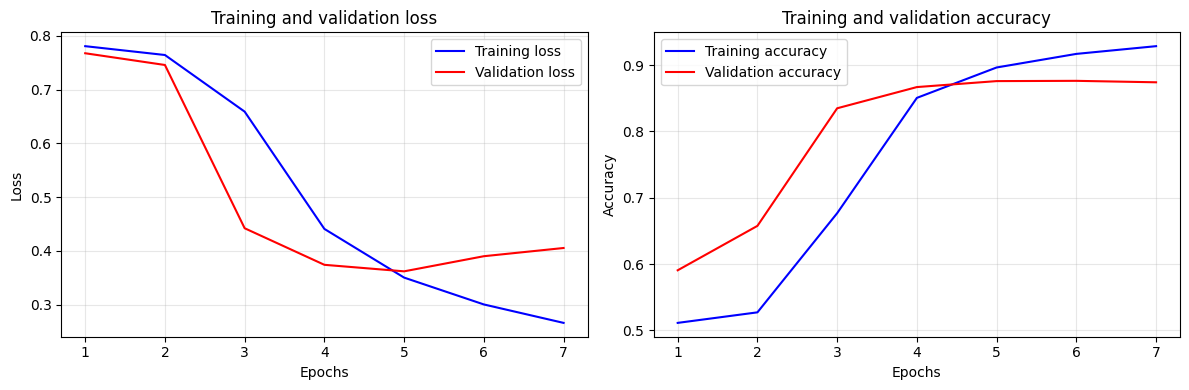


 2 Number of Heads : 1 encoder layer(s) : 0.0001 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_22_1/token_and_position_embedding_20_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_22_1/token_and_position_embedding_20_1/add:0", shape=(32, 200, 64), dtype=float32) training True
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5050 - loss: 0.7136 - precision: 0.5020Input Tensor("functional_22_1/token_and_position_embedding_20_1/add:0", shape=(None, 200, 64), dtype=float32) training False
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5050 - loss: 0.7136 - precision: 0.5020 - val_accuracy: 0.5120 - val_loss: 0.6925 - val_precision: 0.8398 - learning_rate: 1.0000e-04
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5414 - loss: 0.6934 - precision: 0.5393 - val_acc

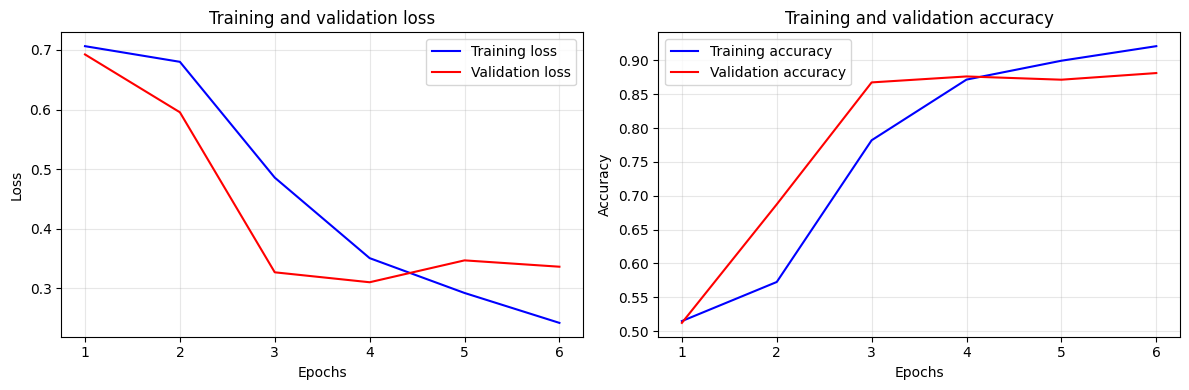


 2 Number of Heads : 1 encoder layer(s) : 1e-05 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_24_1/token_and_position_embedding_21_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_24_1/token_and_position_embedding_21_1/add:0", shape=(32, 200, 64), dtype=float32) training True
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4991 - loss: 0.7147 - precision: 0.4966Input Tensor("functional_24_1/token_and_position_embedding_21_1/add:0", shape=(None, 200, 64), dtype=float32) training False
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.4991 - loss: 0.7146 - precision: 0.4967 - val_accuracy: 0.6472 - val_loss: 0.6834 - val_precision: 0.7537 - learning_rate: 1.0000e-04
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5595 - loss: 0.6803 - precision: 0.5502 - val_acc

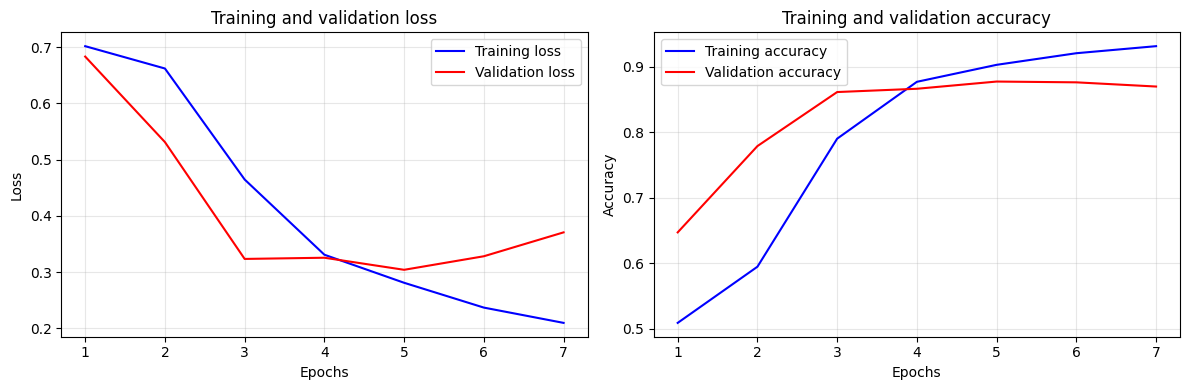


 2 Number of Heads : 1 encoder layer(s) : 1e-06 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_26_1/token_and_position_embedding_22_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_26_1/token_and_position_embedding_22_1/add:0", shape=(32, 200, 64), dtype=float32) training True
620/625 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5115 - loss: 0.7084 - precision: 0.5081Input Tensor("functional_26_1/token_and_position_embedding_22_1/add:0", shape=(None, 200, 64), dtype=float32) training False
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.5116 - loss: 0.7083 - precision: 0.5082 - val_accuracy: 0.6144 - val_loss: 0.6885 - val_precision: 0.6209 - learning_rate: 1.0000e-04
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5492 - loss: 0.6851 - precision: 0.5494 - val_accu

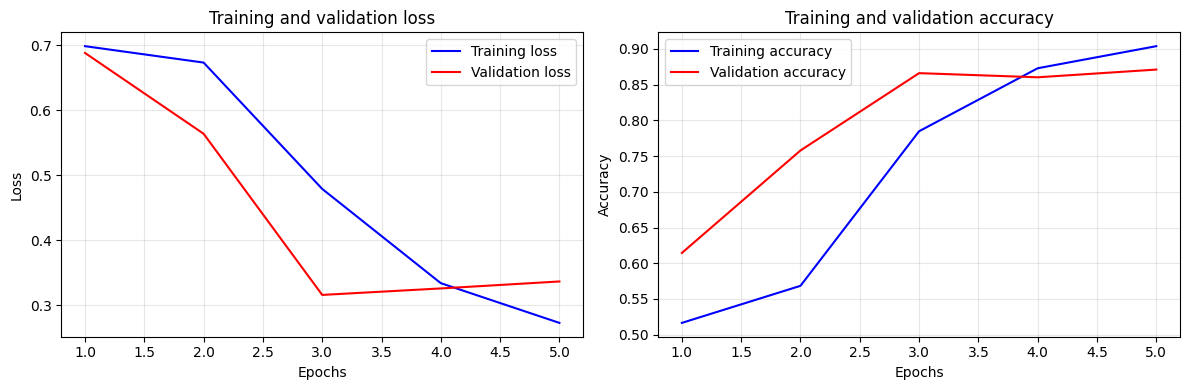


 2 Number of Heads : 2 encoder layer(s) : 0.001 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_29_1/token_and_position_embedding_23_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_29_1/transformer_encoder_block_4_1/layer_normalization_9_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_29_1/token_and_position_embedding_23_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_29_1/transformer_encoder_block_4_1/layer_normalization_9_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5013 - loss: 0.796

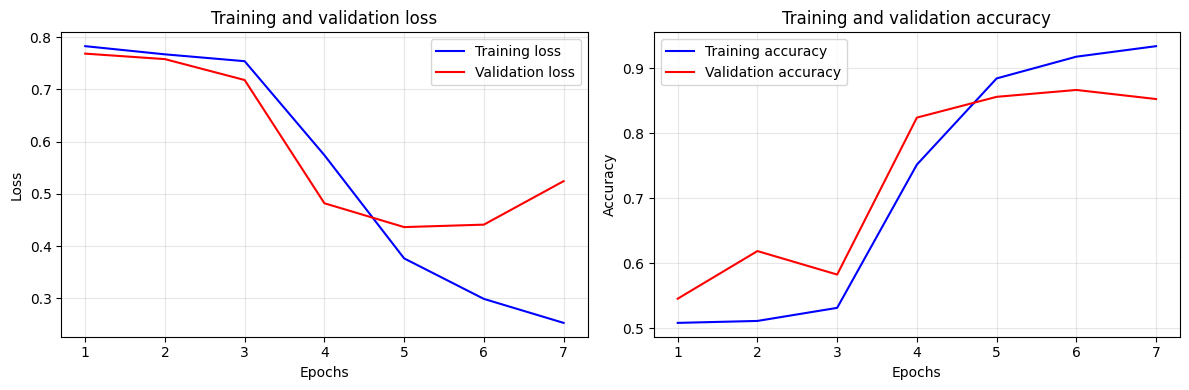


 2 Number of Heads : 2 encoder layer(s) : 0.0001 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_32_1/token_and_position_embedding_24_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_32_1/transformer_encoder_block_6_1/layer_normalization_13_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_32_1/token_and_position_embedding_24_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_32_1/transformer_encoder_block_6_1/layer_normalization_13_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4999 - loss: 0.

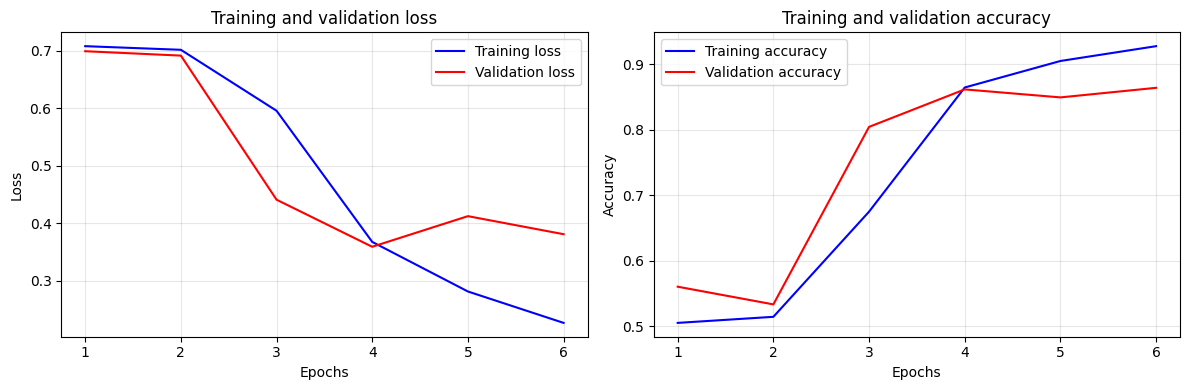


 2 Number of Heads : 2 encoder layer(s) : 1e-05 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_35_1/token_and_position_embedding_25_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_35_1/transformer_encoder_block_8_1/layer_normalization_17_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_35_1/token_and_position_embedding_25_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_35_1/transformer_encoder_block_8_1/layer_normalization_17_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5061 - loss: 0.7

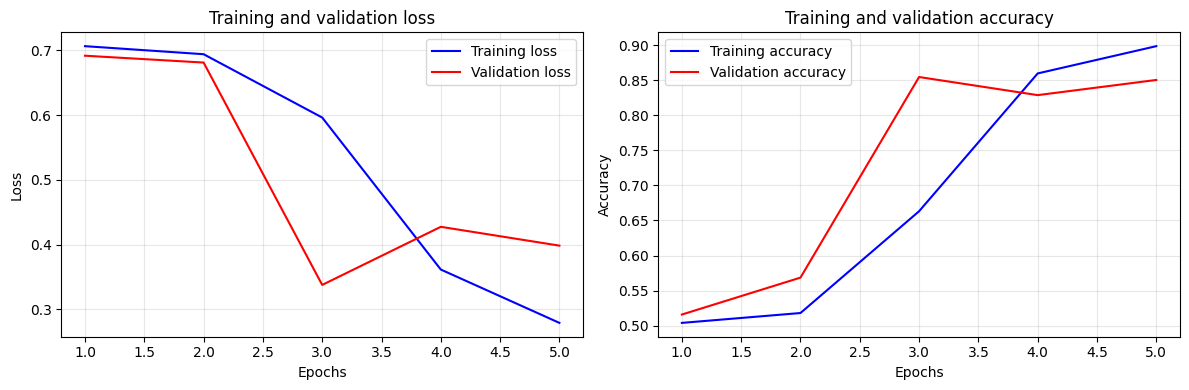


 2 Number of Heads : 2 encoder layer(s) : 1e-06 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_38_1/token_and_position_embedding_26_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_38_1/transformer_encoder_block_10_1/layer_normalization_21_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_38_1/token_and_position_embedding_26_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_38_1/transformer_encoder_block_10_1/layer_normalization_21_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4924 - loss: 0

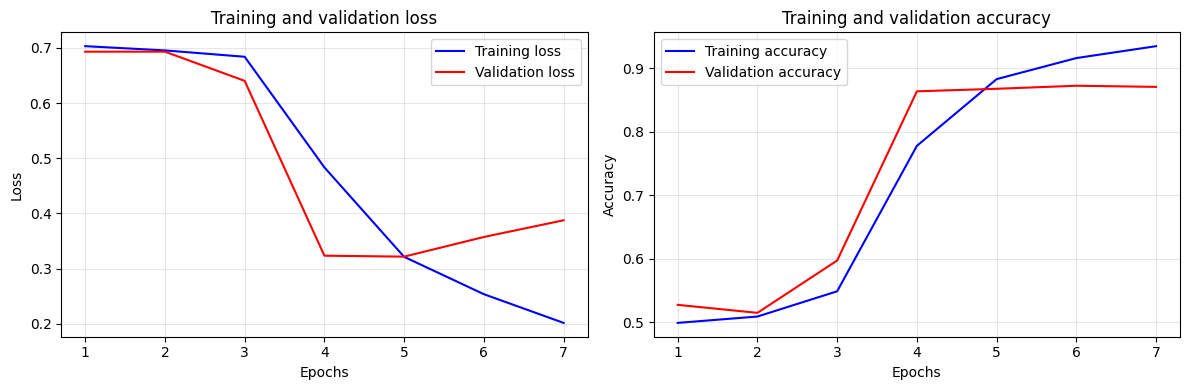


 2 Number of Heads : 4 encoder layer(s) : 0.001 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_43_1/token_and_position_embedding_27_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_43_1/transformer_encoder_block_12_1/layer_normalization_25_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
Input Ten

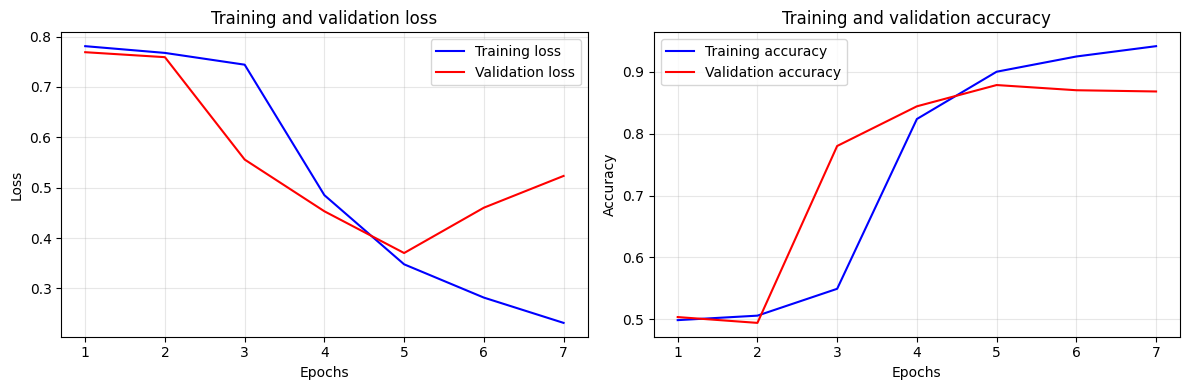


 2 Number of Heads : 4 encoder layer(s) : 0.0001 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_48_1/token_and_position_embedding_28_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_48_1/transformer_encoder_block_16_1/layer_normalization_33_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
Input Te

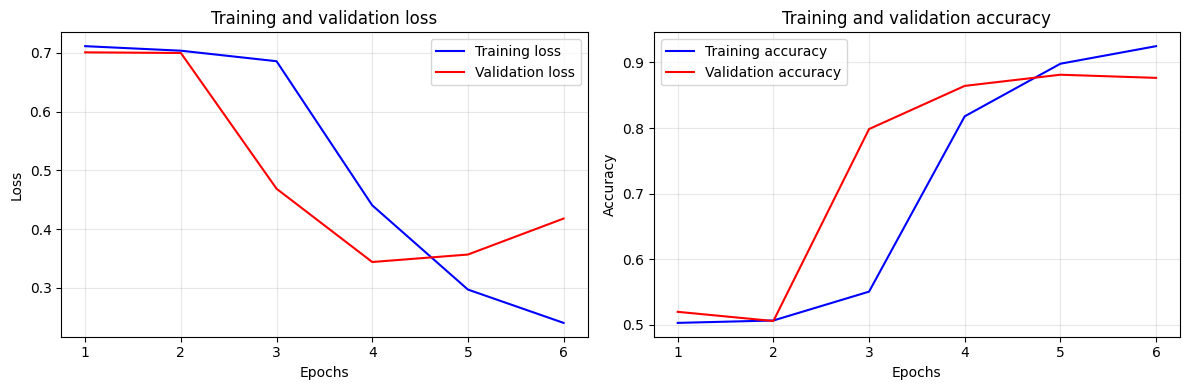


 2 Number of Heads : 4 encoder layer(s) : 1e-05 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_53_1/token_and_position_embedding_29_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_53_1/transformer_encoder_block_20_1/layer_normalization_41_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
Input Ten

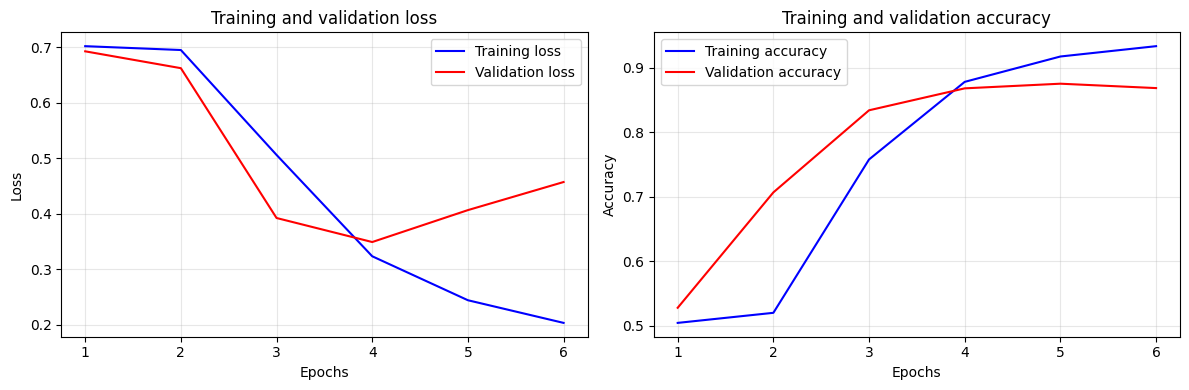


 2 Number of Heads : 4 encoder layer(s) : 1e-06 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_58_1/token_and_position_embedding_30_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_58_1/transformer_encoder_block_24_1/layer_normalization_49_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
Input Ten

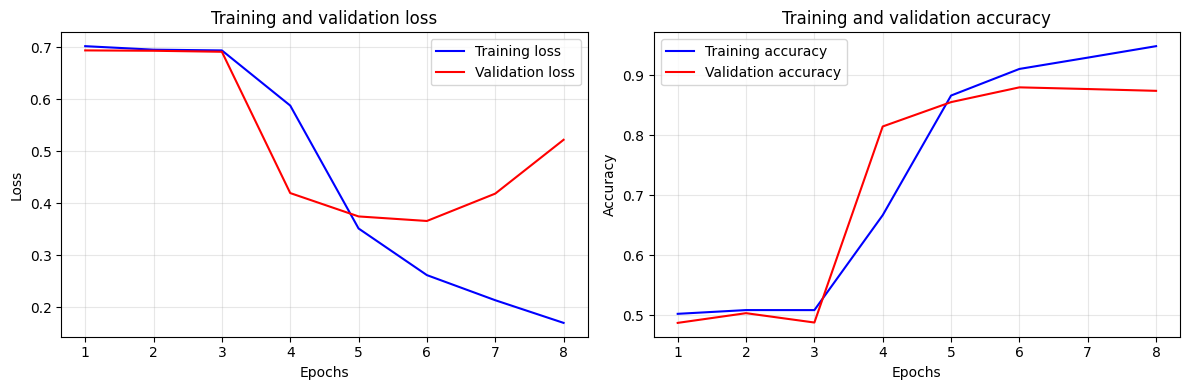


 3 Number of Heads : 1 encoder layer(s) : 0.001 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_60_1/token_and_position_embedding_31_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_60_1/token_and_position_embedding_31_1/add:0", shape=(32, 200, 64), dtype=float32) training True
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5002 - loss: 0.7888 - precision: 0.4973Input Tensor("functional_60_1/token_and_position_embedding_31_1/add:0", shape=(None, 200, 64), dtype=float32) training False
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.5002 - loss: 0.7888 - precision: 0.4973 - val_accuracy: 0.5578 - val_loss: 0.7691 - val_precision: 0.7037 - learning_rate: 1.0000e-04
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5115 - loss: 0.7702 - precision: 0.5077 - val_acc

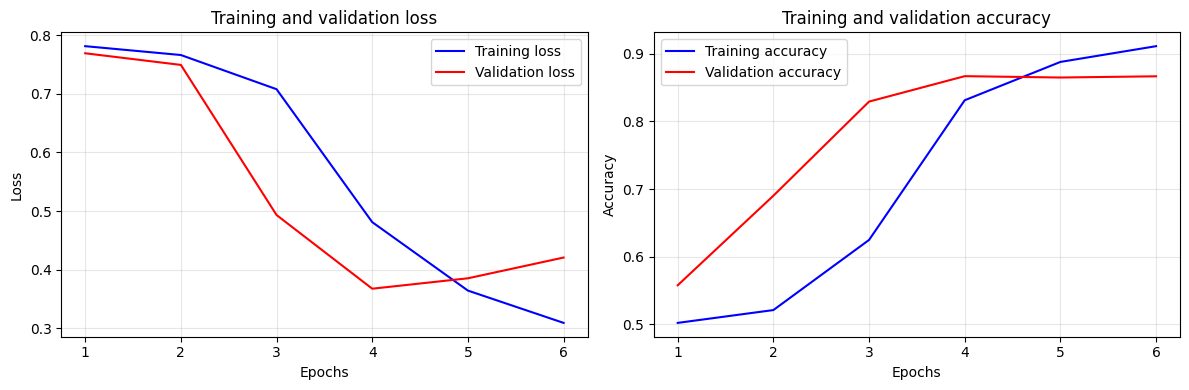


 3 Number of Heads : 1 encoder layer(s) : 0.0001 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_62_1/token_and_position_embedding_32_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_62_1/token_and_position_embedding_32_1/add:0", shape=(32, 200, 64), dtype=float32) training True
620/625 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5022 - loss: 0.7164 - precision: 0.4993Input Tensor("functional_62_1/token_and_position_embedding_32_1/add:0", shape=(None, 200, 64), dtype=float32) training False
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.5023 - loss: 0.7164 - precision: 0.4993 - val_accuracy: 0.6014 - val_loss: 0.6977 - val_precision: 0.5976 - learning_rate: 1.0000e-04
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5181 - loss: 0.7018 - precision: 0.5155 - val_ac

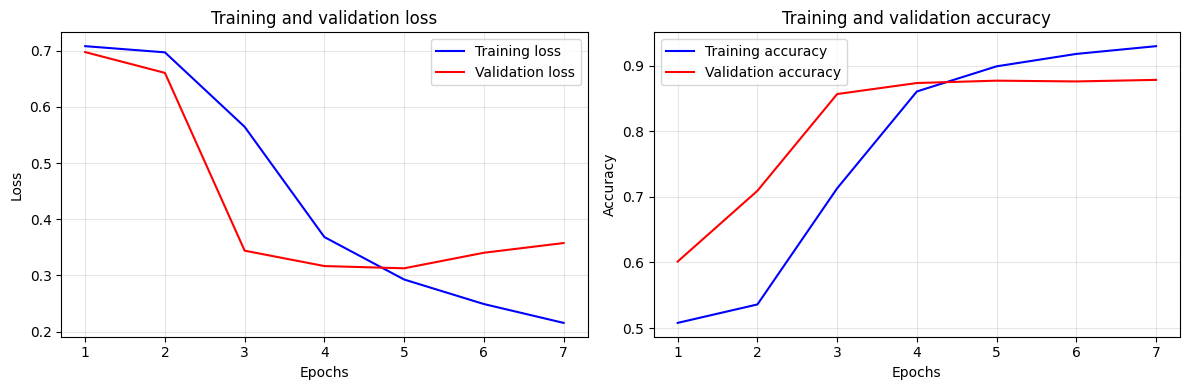


 3 Number of Heads : 1 encoder layer(s) : 1e-05 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_64_1/token_and_position_embedding_33_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_64_1/token_and_position_embedding_33_1/add:0", shape=(32, 200, 64), dtype=float32) training True
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5095 - loss: 0.7060 - precision: 0.5080Input Tensor("functional_64_1/token_and_position_embedding_33_1/add:0", shape=(None, 200, 64), dtype=float32) training False
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.5095 - loss: 0.7060 - precision: 0.5080 - val_accuracy: 0.5852 - val_loss: 0.6912 - val_precision: 0.5860 - learning_rate: 1.0000e-04
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5261 - loss: 0.6937 - precision: 0.5239 - val_acc

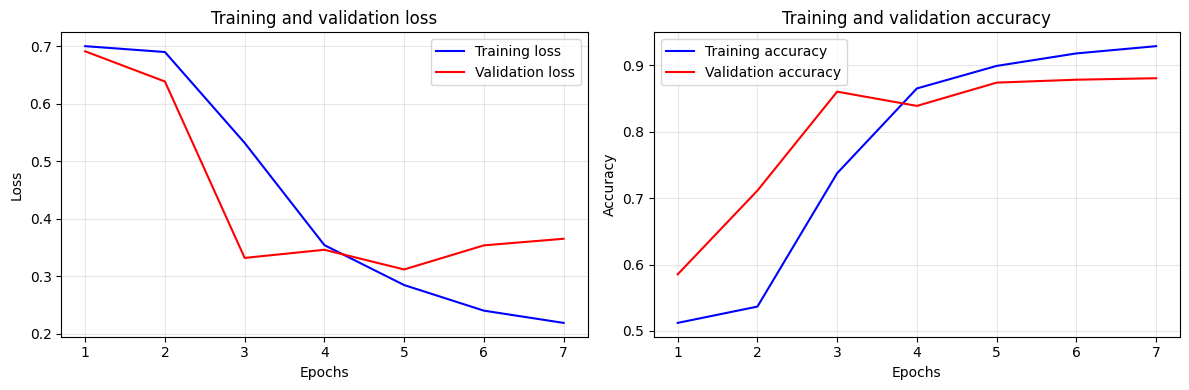


 3 Number of Heads : 1 encoder layer(s) : 1e-06 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_66_1/token_and_position_embedding_34_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_66_1/token_and_position_embedding_34_1/add:0", shape=(32, 200, 64), dtype=float32) training True
621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5042 - loss: 0.7067 - precision: 0.5009Input Tensor("functional_66_1/token_and_position_embedding_34_1/add:0", shape=(None, 200, 64), dtype=float32) training False
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5042 - loss: 0.7066 - precision: 0.5009 - val_accuracy: 0.6054 - val_loss: 0.6860 - val_precision: 0.5821 - learning_rate: 1.0000e-04
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5444 - loss: 0.6844 - precision: 0.5461 - val_acc

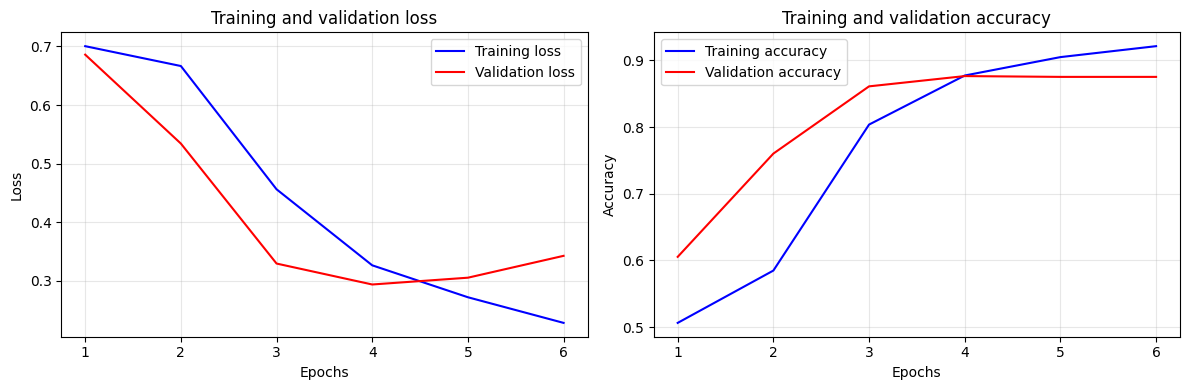


 3 Number of Heads : 2 encoder layer(s) : 0.001 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_69_1/token_and_position_embedding_35_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_69_1/transformer_encoder_block_32_1/layer_normalization_65_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_69_1/token_and_position_embedding_35_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_69_1/transformer_encoder_block_32_1/layer_normalization_65_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5014 - loss: 

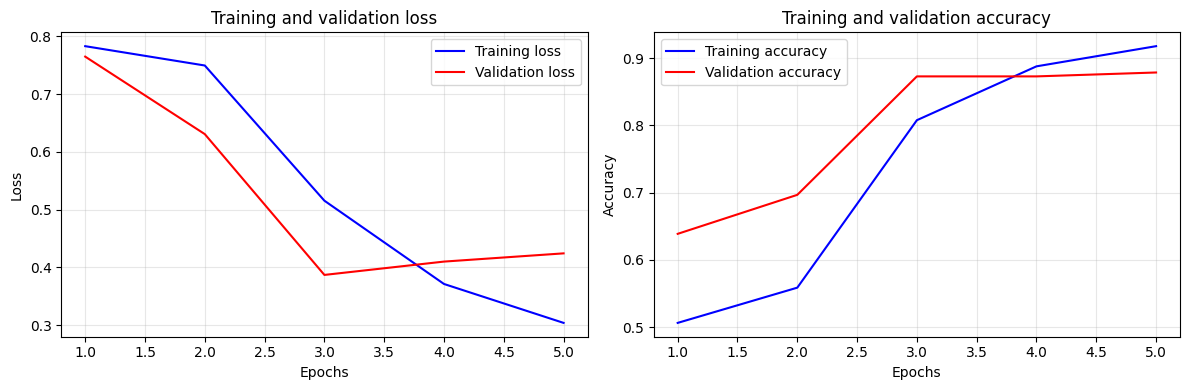


 3 Number of Heads : 2 encoder layer(s) : 0.0001 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_72_1/token_and_position_embedding_36_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_72_1/transformer_encoder_block_34_1/layer_normalization_69_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_72_1/token_and_position_embedding_36_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_72_1/transformer_encoder_block_34_1/layer_normalization_69_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4969 - loss:

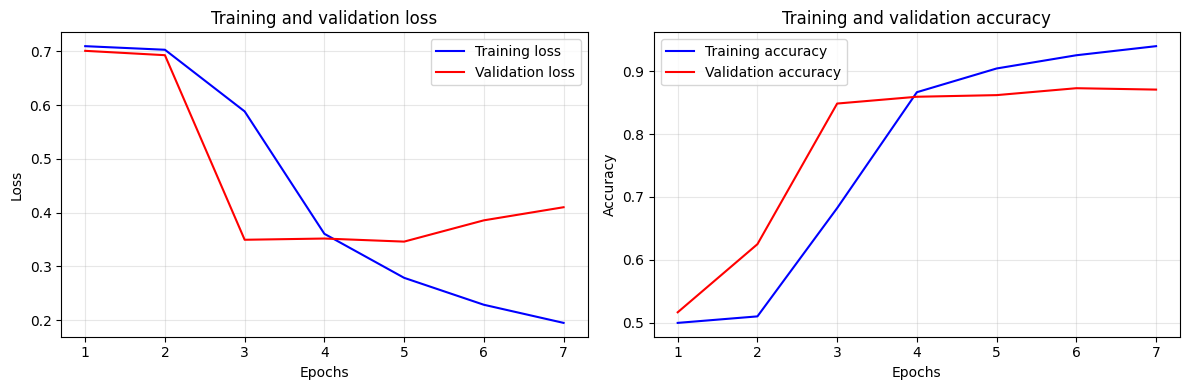


 3 Number of Heads : 2 encoder layer(s) : 1e-05 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_75_1/token_and_position_embedding_37_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_75_1/transformer_encoder_block_36_1/layer_normalization_73_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_75_1/token_and_position_embedding_37_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_75_1/transformer_encoder_block_36_1/layer_normalization_73_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5009 - loss: 

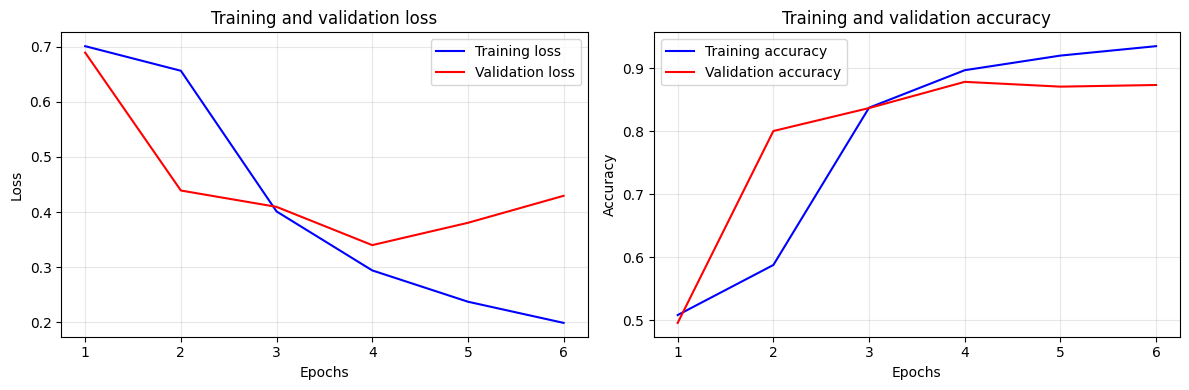


 3 Number of Heads : 2 encoder layer(s) : 1e-06 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_78_1/token_and_position_embedding_38_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_78_1/transformer_encoder_block_38_1/layer_normalization_77_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_78_1/token_and_position_embedding_38_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_78_1/transformer_encoder_block_38_1/layer_normalization_77_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4960 - loss: 

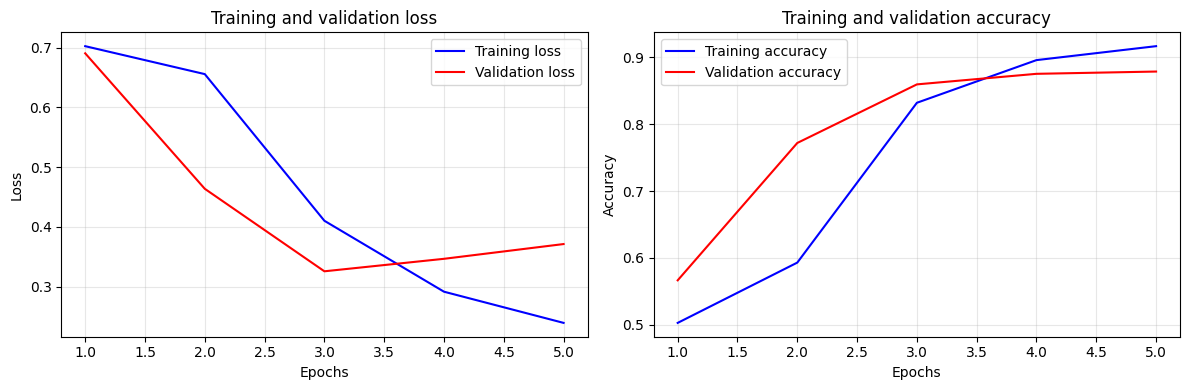


 3 Number of Heads : 4 encoder layer(s) : 0.001 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_83_1/token_and_position_embedding_39_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_83_1/transformer_encoder_block_40_1/layer_normalization_81_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
Input Ten

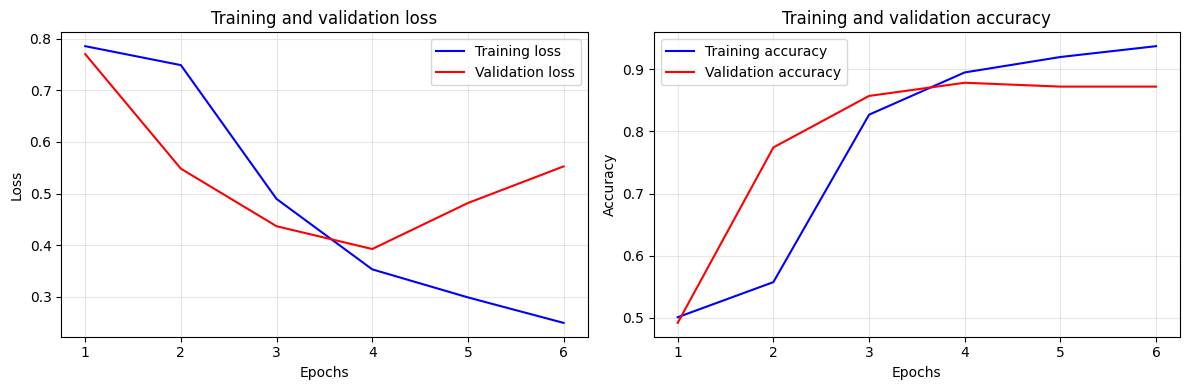


 3 Number of Heads : 4 encoder layer(s) : 0.0001 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_88_1/token_and_position_embedding_40_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_88_1/transformer_encoder_block_44_1/layer_normalization_89_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
Input Te

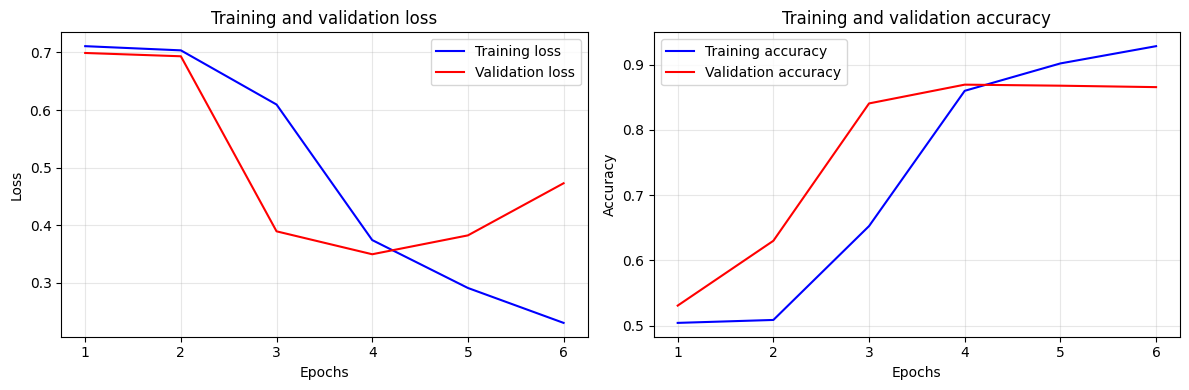


 3 Number of Heads : 4 encoder layer(s) : 1e-05 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_93_1/token_and_position_embedding_41_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_93_1/transformer_encoder_block_48_1/layer_normalization_97_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
Input Ten

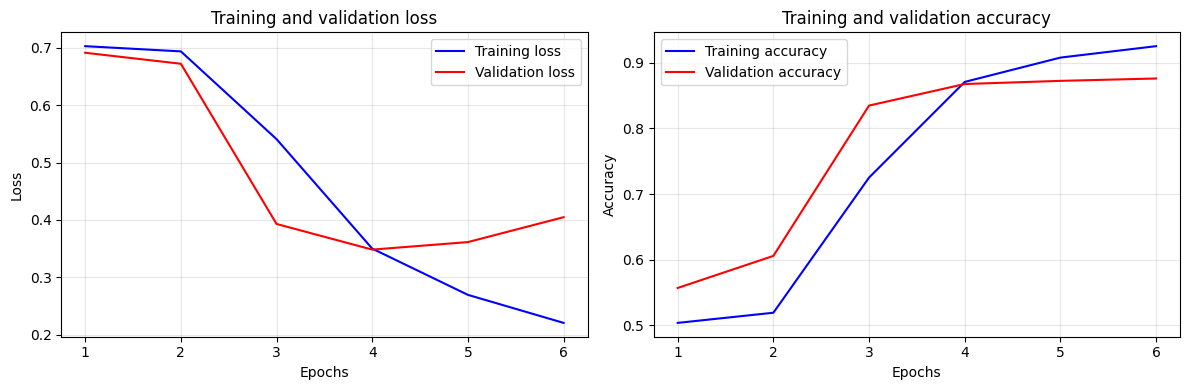


 3 Number of Heads : 4 encoder layer(s) : 1e-06 Lamdas
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Input Tensor("Placeholder:0", shape=(None, 200, 64), dtype=float32) training None
Epoch 1/10
Input Tensor("functional_98_1/token_and_position_embedding_42_1/add:0", shape=(32, 200, 64), dtype=float32) training True
Input Tensor("functional_98_1/transformer_encoder_block_52_1/layer_normalization_105_1/add_2:0", shape=(32, 200, 64), dtype=float32) training True
Input Te

KeyboardInterrupt: 

In [ ]:
embed_dim=64
ff_dim = 64
## Baseline Transformer model
def build_model_custom(num_encoder_layers=1, num_heads=2, lamda=1e-4):
    inputs = layers.Input(shape=(maxlen,))
    x = TokenAndPositionEmbedding(maxlen, vocab_size=max_features, embed_dim=embed_dim)(inputs)
    for _ in range(num_encoder_layers):
        x = TransformerEncoderBlock(
            embed_dim=embed_dim,
            ff_dim=ff_dim,
            rate=0.5,
            num_heads=num_heads
        )(x)
    l2 = keras.regularizers.l2(lamda)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(32, activation="relu", kernel_regularizer=l2)(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=l2)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    
    return keras.Model(inputs, outputs)

# learning rate scheduler
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

encoder_layers =  [1, 2, 4]
num_heads = [2,3, 4]
results = []
lamdas = [1e-3, 1e-4, 1e-5, 1e-6]
for nh in num_heads:  
    # print(f"{nh} Number of Heads ") 
    for el in encoder_layers:
        for lam in lamdas:
            print(f"\n {nh} Number of Heads : {el} encoder layer(s) : {lam} Lamdas")
            model = build_model_custom(num_encoder_layers=el,num_heads=nh, lamda=lam)
            optimizer = keras.optimizers.Adam(learning_rate=1e-4)
            
            model.compile(optimizer=optimizer,loss='binary_crossentropy', metrics =['accuracy', 'precision'])
            history = model.fit(x_train, y_train, 
                    epochs          = 20,
                    validation_data = (x_val, y_val),
                    callbacks       = [reduce_lr, early_stop])
            model.evaluate(x_test, y_test)
            log_run_with_plots(history=history)
            
            val_acc = history.history["val_accuracy"][-1]
            acc = history.history["accuracy"][-1]
            val_loss = history.history["val_loss"][-1]
            loss = history.history["loss"][-1]
            
            
            results.append({
                "num_heads": nh,
                "el": el,
                "lambda": lam,
                "val_accuracy": round(val_acc, 4),
                "val_loss": round(val_loss, 4),
                "acc_gap": acc-val_acc,
                "loss_gap": loss-val_loss,  
            })
tablize(results)

In [ ]:
check_best_model(results)

Best model
 num_heads  el  lambda  val_accuracy  val_loss  acc_gap  loss_gap
         3   1  0.0001         0.876    0.3973   0.0819 -0.250466


Best model
 num_heads  el  lambda  val_accuracy  val_loss  acc_gap  loss_gap
         3   1 0.00001        0.8836    0.3169  0.04905  -0.09939

In [ ]:
print(tf.__version__)

2.19.0
